In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from astropy import constants, units

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = ''

In [4]:
def read_uvb(rootdir, filename):
    
    # First read in the file, line by line
    with open(rootdir+filename) as file:
        uvb_lines = [line.rstrip() for line in file]
        
    # Next, isolate a grid of redshifts
    
    # Specify default delimiter
    # Necessary for processing later
    
    # HM05 and 12
    if filename == 'hm05_galaxy.ascii' or filename == 'hm12_galaxy.ascii':
        dm = '  '
    # FG20
    else:
        dm = ' '

    # Read all lines relevant to redshift
    uvb_lines_z_grid = uvb_lines[uvb_lines.index('# z_grid')+1: uvb_lines.index('# wav_grid')]
    # Split apart the strings
    uvb_lines_z_grid_split = [z_grid_str.strip().replace(dm,',').split(',') for z_grid_str in uvb_lines_z_grid]
    # Flatten the list
    uvb_lines_z_grid_flat = [item for sublist in uvb_lines_z_grid_split for item in sublist]
    # Numpy-fy and flatten
    uvb_z_grid = np.array(uvb_lines_z_grid_flat, dtype='float')
   
    # Next, get the grid of wavelengths
    
    # Read in all lines relevant to wavelength
    uvb_lines_wav_grid = uvb_lines[uvb_lines.index('# wav_grid')+1: uvb_lines.index('# f_nu_list')]
    # Split apart the strings
    uvb_lines_wav_grid_split = [wav_grid_str.strip().replace(dm, ',').split(',') for wav_grid_str in uvb_lines_wav_grid]
    # Flatten the list
    uvb_lines_wav_grid_flat = [item for sublist in uvb_lines_wav_grid_split for item in sublist]
    #print(uvb_lines_wav_grid_split)
    # Numpy-fy and flatten
    uvb_wav_grid = np.array(uvb_lines_wav_grid_flat, dtype='float').flatten()    
    
    # Read in the list of f_nu and reshape
    uvb_lines_J_nu_list = uvb_lines[uvb_lines.index('# f_nu_list')+1:]
    # Split apart the strings
    uvb_lines_J_nu_split = [J_nu_str.strip().replace(dm, ',').split(',') for J_nu_str in uvb_lines_J_nu_list]
    # Flatten and reshape
    uvb_J_nu_grid = np.array([item for sublist in uvb_lines_J_nu_split for item in sublist], dtype='float').reshape((len(uvb_z_grid), len(uvb_wav_grid))) 
    
    return uvb_z_grid, uvb_wav_grid, uvb_J_nu_grid

In [5]:
# Isolate data form HM05, HM12, FG20
hm05_z_grid, hm05_wav_grid, hm05_J_nu_grid = read_uvb(rootdir, 'hm05_galaxy.ascii')
hm12_z_grid, hm12_wav_grid, hm12_J_nu_grid = read_uvb(rootdir, 'hm12_galaxy.ascii')
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb(rootdir, 'fg20_galaxy.ascii')

In [6]:
from astropy import constants
from astropy import units

def wav_2_ryd(wav):
    # Wavelength in Angstrom, convert to m
    # Astropy has Ryd in inverse meters
    return 1/(wav*1e-10*constants.Ryd.value)

In [7]:
# Convert wavelength grids to energies
hm05_ryd_grid = wav_2_ryd(hm05_wav_grid)
hm12_ryd_grid = wav_2_ryd(hm12_wav_grid)
fg20_ryd_grid = wav_2_ryd(fg20_wav_grid)

In [8]:
def fetch_sed(z, uvb_z_grid, uvb_J_nu_grid):
    
    # First find the redshift closest to the desired one 
    # Search the redshift grid for the same
    
    idx = np.argmin(np.abs(uvb_z_grid-z))
    
    # Isolate f_nu
    
    uvb_J_nu = uvb_J_nu_grid[idx]
    
    return uvb_J_nu

In [9]:
z_test = 1

In [10]:
hm05_J_nu_test = fetch_sed(z_test, hm05_z_grid, hm05_J_nu_grid)
hm12_J_nu_test = fetch_sed(z_test, hm12_z_grid, hm12_J_nu_grid)
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

In [11]:
IP_dict = {'CIII': 24.383/13.61,
            'OIII': 35.117/13.61,
            'CIV': 47.887/13.61,
            'OIV': 54.934/13.61,
            'OV': 77.413/13.61,
            'OVI': 113.9/13.61}

In [26]:
hm12_J_nu_test_interp = np.flip(10**np.interp(np.flip(np.log10(fg20_ryd_grid)), 
                                     np.flip(np.log10(hm12_ryd_grid)),
                                     np.flip(np.log10(hm12_J_nu_test))))

In [77]:
hm12_J_nu_test_interp

array([8.81025824e-29, 9.02082648e-29, 9.23279851e-29, 9.45122976e-29,
       9.67638020e-29, 9.90852010e-29, 1.01479032e-28, 1.03947924e-28,
       1.06443769e-28, 1.08966082e-28, 1.11566936e-28, 1.14249113e-28,
       1.17016366e-28, 1.19871430e-28, 1.22818025e-28, 1.25831944e-28,
       1.28936215e-28, 1.32141702e-28, 1.35452013e-28, 1.38871529e-28,
       1.42404811e-28, 1.45977444e-28, 1.49597106e-28, 1.53335887e-28,
       1.57199291e-28, 1.61192370e-28, 1.65320383e-28, 1.69551000e-28,
       1.73885194e-28, 1.78367258e-28, 1.83003837e-28, 1.87801489e-28,
       1.92767801e-28, 1.97794926e-28, 2.02960310e-28, 2.08307995e-28,
       2.13845153e-28, 2.19580842e-28, 2.25437639e-28, 2.31331043e-28,
       2.37434508e-28, 2.43757301e-28, 2.50309916e-28, 2.57093350e-28,
       2.64029616e-28, 2.71221704e-28, 2.78682025e-28, 2.86423546e-28,
       2.94423326e-28, 3.02501424e-28, 3.10885934e-28, 3.19591201e-28,
       3.28633628e-28, 3.37968208e-28, 3.47566085e-28, 3.57542867e-28,
      

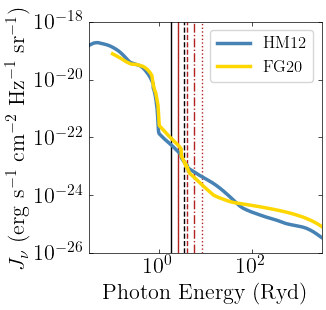

In [86]:
fig, ax = plt.subplots(1, figsize=(3,3))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-26,1e-18)
ax.set_xlim(10**-1.5, 10**3.5)

ax.axvline(IP_dict['CIII'], linestyle='-', color='black', lw=1)
ax.axvline(IP_dict['CIV'], linestyle='--', color='black', lw=1)

ax.axvline(IP_dict['OIII'], linestyle='-', color='firebrick', lw=1)
ax.axvline(IP_dict['OIV'], linestyle='--', color='firebrick', lw=1)
ax.axvline(IP_dict['OV'], linestyle='-.', color='firebrick', lw=1)
ax.axvline(IP_dict['OVI'], linestyle=':', color='firebrick', lw=1)


#ax.plot(hm05_ryd_grid, hm05_J_nu_test, label='HM05')
ax.plot(hm12_ryd_grid, hm12_J_nu_test, lw=2.5, label=r'HM12', color='steelblue')
ax.plot(fg20_ryd_grid, fg20_J_nu_test, lw=2.5, label=r'FG20', color='gold')

#ax.set_title('$z$={}'.format(z_test))
ax.set_xlabel('Photon Energy (Ryd)')
ax.set_ylabel(r'$J_\nu \ (\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{cm}^{-2} \ \mathrm{Hz}^{-1} \ \mathrm{sr}^{-1})$')

#ax.axvline(1, linestyle=':')

ax.legend()

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(3.3,5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylim(1e-25,1e-18)
axes[0].set_xlim(10**-1.03, 10**3.5)

#ax.axvline(IP_dict['CIII'], linestyle='-', color='black', lw=1)
#ax.axvline(IP_dict['CIV'], linestyle='--', color='black', lw=1)

#ax.axvline(IP_dict['OIII'], linestyle='-', color='firebrick', lw=1)
#ax.axvline(IP_dict['OIV'], linestyle='--', color='firebrick', lw=1)
#ax.axvline(IP_dict['OV'], linestyle='-.', color='firebrick', lw=1)
#ax.axvline(IP_dict['OVI'], linestyle=':', color='firebrick', lw=1)


#ax.plot(hm05_ryd_grid, hm05_J_nu_test, label='HM05')
#ax.plot(fg20_ryd_grid, hm12_J_nu_test_interp, lw=2.5, label='HM12', color='steelblue')
axes[0].plot(fg20_ryd_grid, fg20_J_nu_test, lw=2.5, label=r'FG20, $z=1$', color='gold')
axes[0].axvline(1, linestyle=':')
#ax.plot(fg20_ryd_grid, fg20_J_nu_test-hm12_J_nu_test_interp, lw=2.5, label='FG20-HM12', color='steelblue')

#axes[0].set_title('$z$={}'.format(z_test))
#axes[0].set_xlabel('Photon Energy (Ryd)')
#axes[0].set_ylabel(r'$J_\nu \ (\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{cm}^{-2} \ \mathrm{Hz}^{-1} \ \mathrm{sr}^{-1})$')

#ax.axvline(1, linestyle=':')

axes[0].legend()

axes[1].plot(fg20_ryd_grid, hm12_J_nu_test_interp-fg20_J_nu_test, lw=2.5, label=r'HM12-FG20, $z=1$', color='steelblue')

axes[1].legend()

ax_label = fig.add_subplot(111, frameon=False)
ax_label.set_xticks([])
ax_label.set_yticks([])

#ax_label.set_title('Time-Dependent Photoionization for an uncertain UVB', fontsize=18)
ax_label.set_xlabel('Photon Energy (Ryd)', labelpad=20)
ax_label.set_ylabel(r'$J_\nu \ (\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{cm}^{-2} \ \mathrm{Hz}^{-1} \ \mathrm{sr}^{-1})$', labelpad=40)

plt.subplots_adjust(wspace=0, hspace=0.2)

#plt.savefig(rootdir+'TDP.pdf', dpi=300)

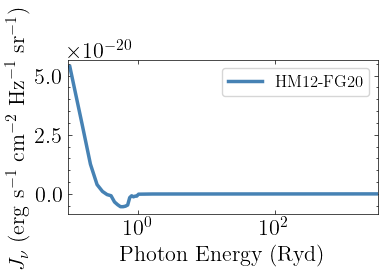

In [81]:
fig, ax = plt.subplots(1, figsize=(4,2))

ax.set_xscale('log')
#ax.set_yscale('log')
#ax.set_ylim(1e-26,1e-18)
ax.set_xlim(10**-1.03, 10**3.5)

#ax.axvline(IP_dict['CIII'], linestyle='-', color='black', lw=1)
#ax.axvline(IP_dict['CIV'], linestyle='--', color='black', lw=1)

#ax.axvline(IP_dict['OIII'], linestyle='-', color='firebrick', lw=1)
#ax.axvline(IP_dict['OIV'], linestyle='--', color='firebrick', lw=1)
#ax.axvline(IP_dict['OV'], linestyle='-.', color='firebrick', lw=1)
#ax.axvline(IP_dict['OVI'], linestyle=':', color='firebrick', lw=1)


#ax.plot(hm05_ryd_grid, hm05_J_nu_test, label='HM05')
#ax.plot(fg20_ryd_grid, hm12_J_nu_test_interp, lw=2.5, label='HM12', color='steelblue')
ax.plot(fg20_ryd_grid, hm12_J_nu_test_interp-fg20_J_nu_test, lw=2.5, label='HM12-FG20', color='steelblue')

#ax.set_title('$z$={}'.format(z_test))
ax.set_xlabel('Photon Energy (Ryd)')
ax.set_ylabel(r'$J_\nu \ (\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{cm}^{-2} \ \mathrm{Hz}^{-1} \ \mathrm{sr}^{-1})$')

#ax.axvline(1, linestyle=':')

ax.legend()

In [13]:
constants.Ryd.value**-1*1e+10

911.2670505823875